# 06 - Final Comparison & Paper Figures
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

Loads all saved results and generates:
- Master comparison table (all PDEs × all conditions)
- Noise level study plots
- Ablation table
- Paper-ready figures

**Run this AFTER all other notebooks have completed.**

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pinn_base import load_metrics, load_history

RESULTS = '../results/'
FIGURES = '../figures/'
os.makedirs(FIGURES+'comparison', exist_ok=True)

PDES = ['burgers', 'heat', 'wave', 'allen_cahn']
PDE_LABELS = {
    'burgers':    "Burgers' ($\\nu=0.01/\\pi$)",
    'heat':       'Heat ($\\alpha=0.01$)',
    'wave':       'Wave ($c=1.0$)',
    'allen_cahn': 'Allen-Cahn ($\\varepsilon=0.01$)',
}
print('Setup complete')

Setup complete


## Section 1 - Load All Benchmark Metrics

In [2]:
all_metrics = {}
for pde in PDES:
    path = RESULTS + f'{pde}/benchmark_metrics.npy'
    if os.path.exists(path):
        all_metrics[pde] = load_metrics(path)
        print(f'Loaded {pde}: {list(all_metrics[pde].keys())}')
    else:
        print(f'WARNING: {path} not found - run notebook first')

Loaded burgers: ['Vanilla (clean)', 'Vanilla (noisy)', 'AC-PINN (clean)', 'AC-PINN (noisy)']
Loaded heat: ['Vanilla (clean)', 'Vanilla (noisy)', 'AC-PINN (clean)', 'AC-PINN (noisy)']
Loaded wave: ['Vanilla (clean)', 'Vanilla (noisy)', 'AC-PINN (clean)', 'AC-PINN (noisy)']
Loaded allen_cahn: ['Vanilla (clean)', 'Vanilla (noisy)', 'AC-PINN (clean)', 'AC-PINN (noisy)']


## Section 2 - Master Comparison Table

In [3]:
print('\n' + '='*85)
print(f"  {'PDE':<20} {'Model':<25} {'Rel L2':>10} {'Max Err':>10} {'MAE':>10}")
print('='*85)

for pde in PDES:
    if pde not in all_metrics:
        continue
    metrics = all_metrics[pde]
    for model_name, vals in metrics.items():
        print(f"  {PDE_LABELS[pde]:<20} {model_name:<25} "
              f"{vals['l2']:>10.6f} {vals['max_error']:>10.6f} {vals['mae']:>10.6f}")
    print('-'*85)
print('='*85)


  PDE                  Model                         Rel L2    Max Err        MAE
  Burgers' ($\nu=0.01/\pi$) Vanilla (clean)             0.174012   1.416779   0.025795
  Burgers' ($\nu=0.01/\pi$) Vanilla (noisy)             0.538481   1.504175   0.183198
  Burgers' ($\nu=0.01/\pi$) AC-PINN (clean)             0.608142   1.016729   0.280975
  Burgers' ($\nu=0.01/\pi$) AC-PINN (noisy)             0.379828   0.966123   0.150614
-------------------------------------------------------------------------------------
  Heat ($\alpha=0.01$) Vanilla (clean)             0.002129   0.004995   0.001146
  Heat ($\alpha=0.01$) Vanilla (noisy)             0.123240   0.224612   0.059022
  Heat ($\alpha=0.01$) AC-PINN (clean)             0.002494   0.006392   0.001321
  Heat ($\alpha=0.01$) AC-PINN (noisy)             0.126721   0.255319   0.058358
-------------------------------------------------------------------------------------
  Wave ($c=1.0$)       Vanilla (clean)             0.016873   0.02187

## Section 3 - Noise Level Study: Vanilla vs AC-PINN

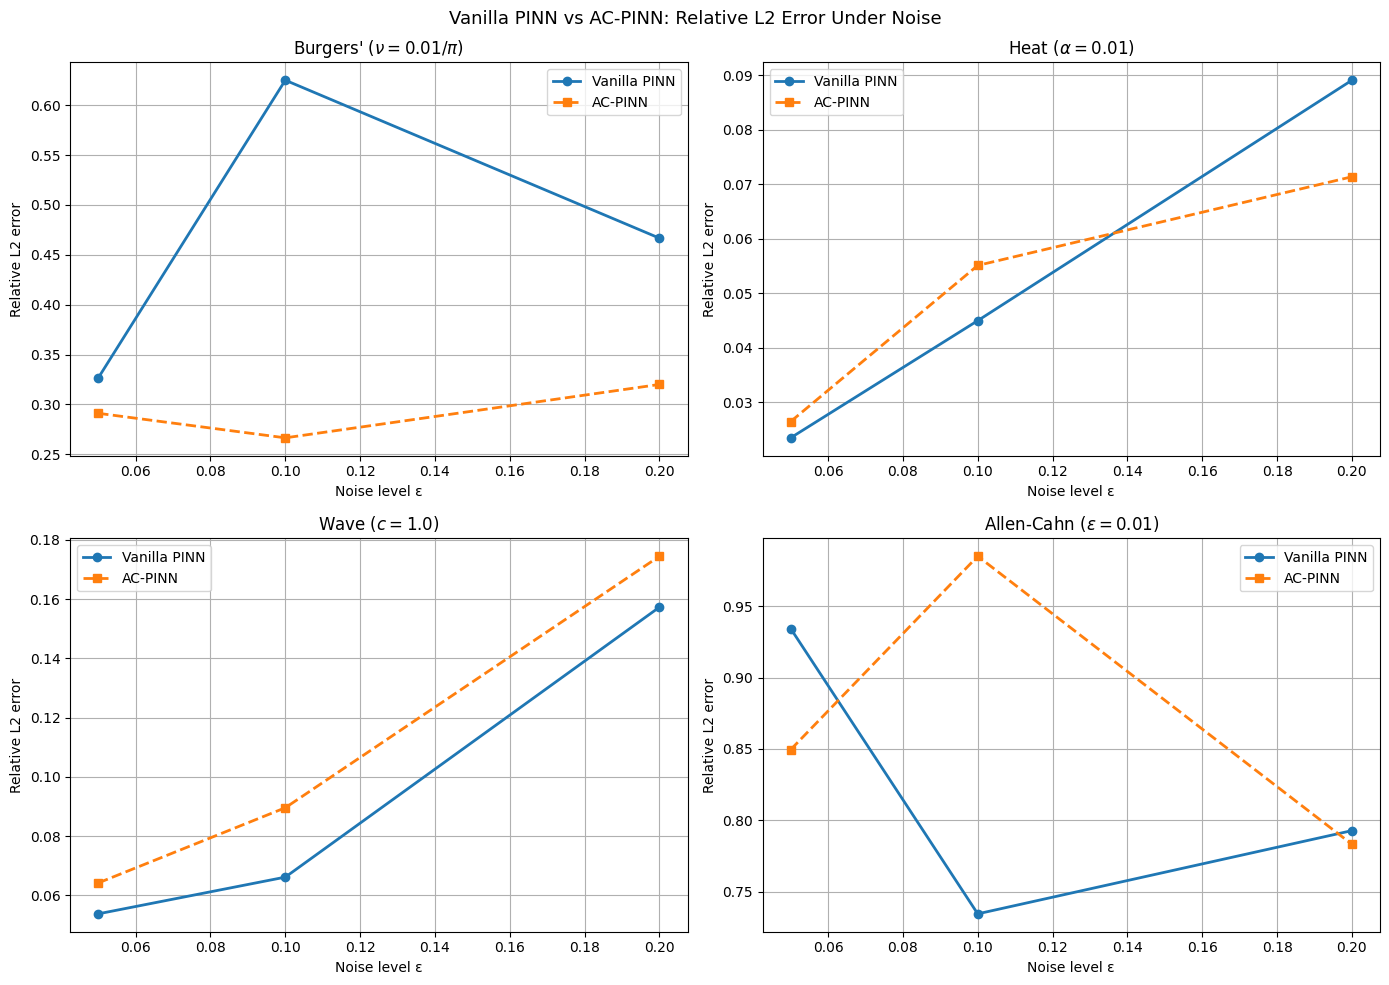

In [4]:
noise_levels = [0.05, 0.1, 0.2]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flat

for ax, pde in zip(axes, PDES):
    path = RESULTS + f'{pde}/noise_study_metrics.npy'
    if not os.path.exists(path):
        ax.set_title(f'{PDE_LABELS[pde]} - data not found')
        continue
    noise_data = load_metrics(path)

    v_l2 = []; a_l2 = []
    for eps in noise_levels:
        if eps not in noise_data:
            continue
        d = noise_data[eps]
        for name, vals in d.items():
            if 'Vanilla' in name:
                v_l2.append(vals['l2'])
            elif 'AC' in name:
                a_l2.append(vals['l2'])

    ax.plot(noise_levels[:len(v_l2)], v_l2, 'o-', lw=2, label='Vanilla PINN')
    ax.plot(noise_levels[:len(a_l2)], a_l2, 's--', lw=2, label='AC-PINN')
    ax.set_xlabel('Noise level ε'); ax.set_ylabel('Relative L2 error')
    ax.set_title(PDE_LABELS[pde])
    ax.legend(); ax.grid(True)

plt.suptitle('Vanilla PINN vs AC-PINN: Relative L2 Error Under Noise', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES+'comparison/noise_study.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 - Ablation Study Results

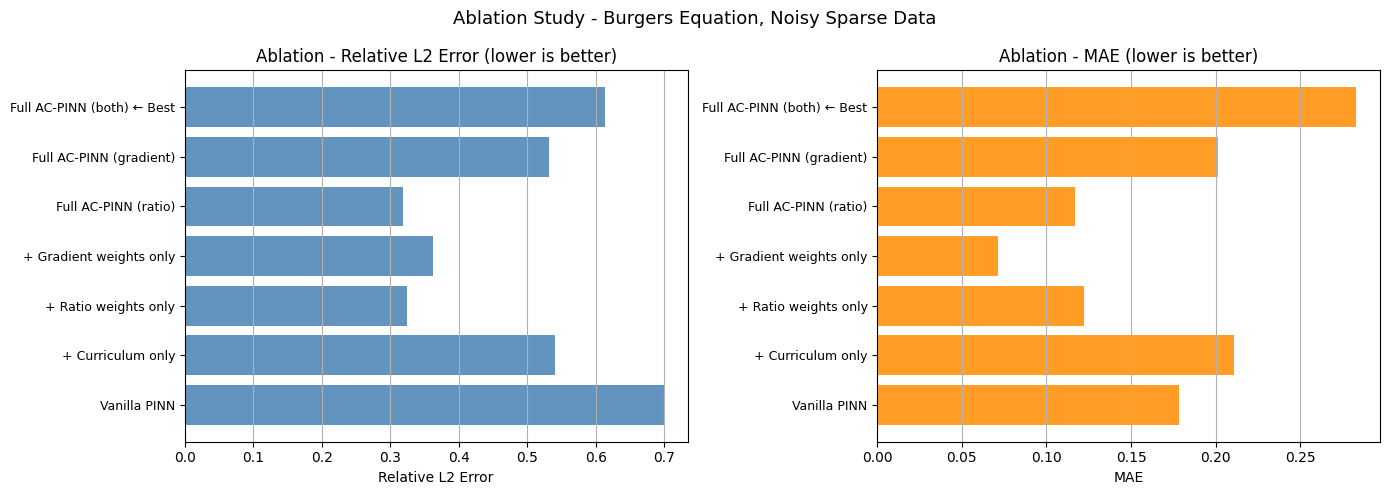


Ablation Table:
  Model                                   Rel L2        MAE
---------------------------------------------------------
  Vanilla PINN                          0.698827   0.178504
  + Curriculum only                     0.540353   0.210746
  + Ratio weights only                  0.324950   0.122444
  + Gradient weights only               0.362893   0.071437
  Full AC-PINN (ratio)                  0.319261   0.117123
  Full AC-PINN (gradient)               0.531736   0.201098
  Full AC-PINN (both) ← Best            0.613590   0.282918


In [5]:
ablation_path = RESULTS + 'burgers/ablation_metrics.npy'
if os.path.exists(ablation_path):
    abl = load_metrics(ablation_path)

    names = list(abl.keys())
    l2s   = [abl[n]['l2']  for n in names]
    maes  = [abl[n]['mae'] for n in names]

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(x, l2s, color='steelblue', alpha=0.85)
    axes[0].set_yticks(x); axes[0].set_yticklabels(names, fontsize=9)
    axes[0].set_xlabel('Relative L2 Error')
    axes[0].set_title('Ablation - Relative L2 Error (lower is better)')
    axes[0].grid(True, axis='x')

    axes[1].barh(x, maes, color='darkorange', alpha=0.85)
    axes[1].set_yticks(x); axes[1].set_yticklabels(names, fontsize=9)
    axes[1].set_xlabel('MAE')
    axes[1].set_title('Ablation - MAE (lower is better)')
    axes[1].grid(True, axis='x')

    plt.suptitle('Ablation Study - Burgers Equation, Noisy Sparse Data', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES+'comparison/ablation_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nAblation Table:')
    print(f"  {'Model':<35} {'Rel L2':>10} {'MAE':>10}")
    print('-'*57)
    for n in names:
        print(f"  {n:<35} {abl[n]['l2']:>10.6f} {abl[n]['mae']:>10.6f}")
else:
    print('Ablation results not found - run 05_ablation.ipynb first')

## Section 5 - Loss Convergence Comparison

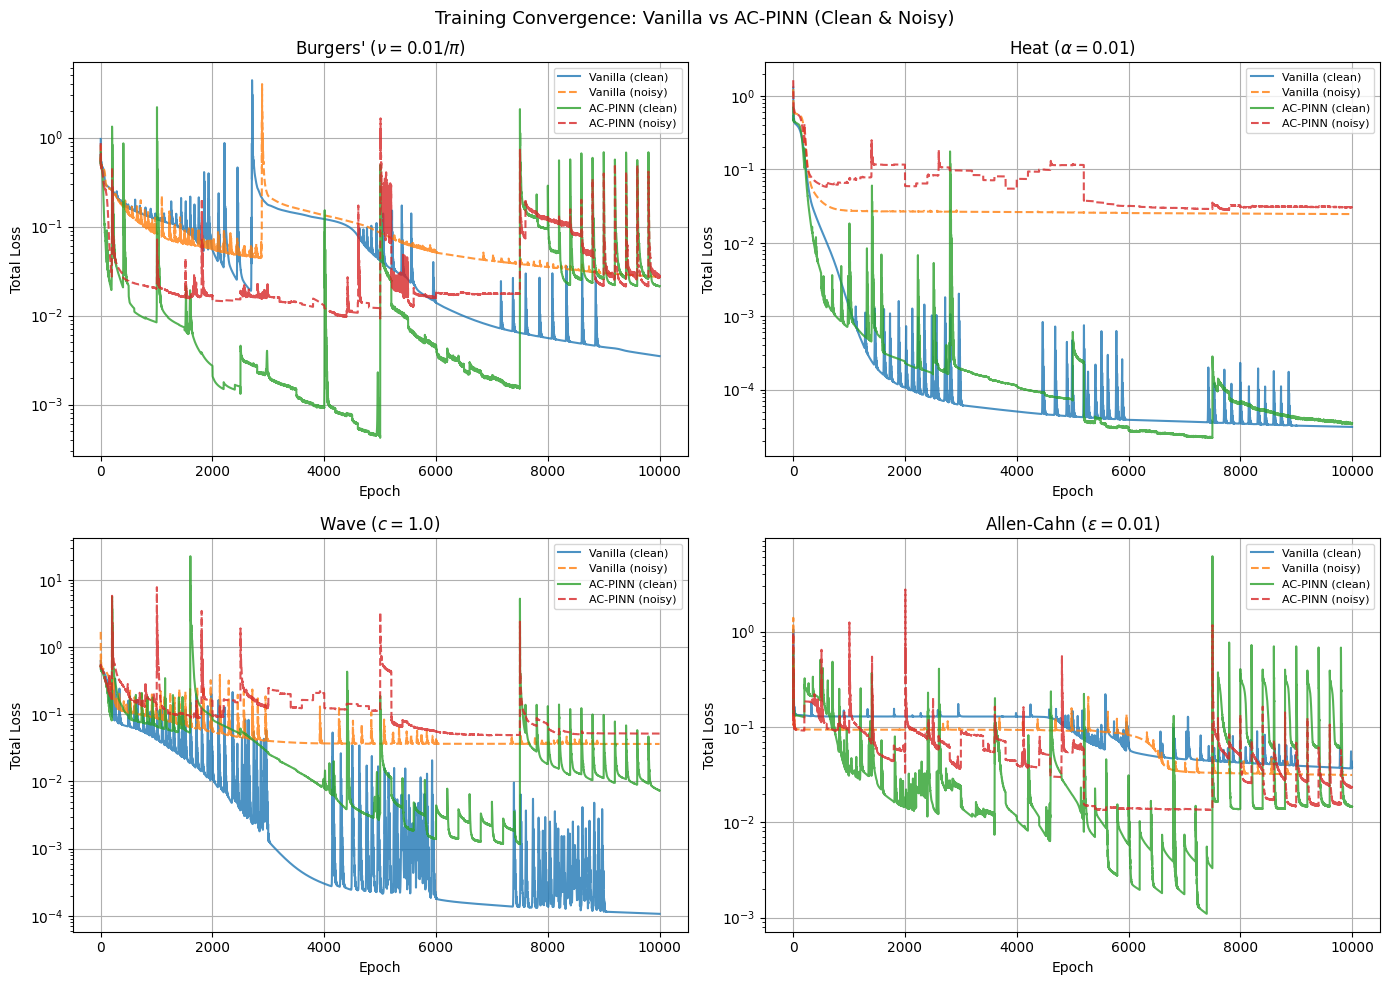

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flat

for ax, pde in zip(axes, PDES):
    vc_path = RESULTS + f'{pde}/vanilla_clean_history.npy'
    ac_path = RESULTS + f'{pde}/ac_clean_history.npy'
    vn_path = RESULTS + f'{pde}/vanilla_noisy_history.npy'
    an_path = RESULTS + f'{pde}/ac_noisy_history.npy'

    for path, label, ls in [
        (vc_path, 'Vanilla (clean)', '-'),
        (vn_path, 'Vanilla (noisy)', '--'),
        (ac_path, 'AC-PINN (clean)', '-'),
        (an_path, 'AC-PINN (noisy)', '--'),
    ]:
        if os.path.exists(path):
            h = load_history(path)
            ax.plot(h['total'], ls, label=label, alpha=0.8)

    ax.set_yscale('log')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Total Loss')
    ax.set_title(PDE_LABELS[pde])
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('Training Convergence: Vanilla vs AC-PINN (Clean & Noisy)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES+'comparison/convergence_all_pdes.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 - Summary
All figures saved to `figures/comparison/`.

In [7]:
print('Paper figures saved:')
for f in os.listdir(FIGURES+'comparison/'):
    print(f'  figures/comparison/{f}')
print('\nAC-PINN Full Suite - Complete.')
print('Authors: Suyash Vasal Jain, Nishita Raghvendra')

Paper figures saved:
  figures/comparison/ablation_bars.png
  figures/comparison/convergence_all_pdes.png
  figures/comparison/noise_study.png

AC-PINN Full Suite - Complete.
Authors: Suyash Vasal Jain, Nishita Raghvendra
